# Vehicle Insurance Fraud Detection — Final Model

This notebook loads the raw CSV, applies the final preprocessing pipeline,
trains the selected model (HistGradientBoostingClassifier), evaluates it on
a held-out test set, and saves the trained pipeline to disk.

It does **not** repeat the full model comparison / hyperparameter search —
that experimentation was done separately; see `results/model_comparison.csv`
and `results/best_model_summary.txt` for those results and the reasoning
behind the final choice.

## 1. Imports

In [1]:
import sys, json
sys.path.insert(0, '../src')  # fraud_preprocessing.py lives here

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                              average_precision_score, precision_recall_fscore_support,
                              RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import joblib

from fraud_preprocessing import load_raw, clean_target, FraudCleaner, QuantileClipper


The import above is intentionally simplified for readability; the real column lists come straight from `fraud_preprocessing.py`.

In [2]:
from fraud_preprocessing import load_raw, clean_target, FraudCleaner, QuantileClipper

SEED = 42

# Skew-based column groups, matching the preprocessing summary
SKEWED = ["annual_income", "past_num_of_claims", "claim_to_price", "injury_share",
          "claim_to_income", "premium_to_income", "claim_to_deductible",
          "total_claim", "vehicle_price", "injury_claim", "policy deductible"]
ALL_CONT = ["age_of_driver", "safety_rating", "annual_income", "past_num_of_claims", "liab_prct",
            "age_of_vehicle", "vehicle_price", "total_claim", "injury_claim", "policy deductible",
            "annual premium", "days open", "form defects", "claim_to_price", "injury_share",
            "claim_to_income", "premium_to_income", "claim_to_deductible"]
NOT_SKEWED = [c for c in ALL_CONT if c not in SKEWED]
BIN_COLS = ["high_education", "address_change", "police_report", "marital_status", "witness_present"]
CAT_COLS = ["gender", "property_status", "accident_site", "channel", "vehicle_category",
            "vehicle_color", "zip_region", "claim_month", "claim_weekday", "claim_year"]


## 2. Load CSV

In [3]:
df = load_raw('../data/original_dataset.csv')
print(df.shape)
df.head()

(12002, 29)


,claim_number,age_of_driver,gender,marital_status,safety_rating,annual_income,high_education,address_change,property_status,zip_code,...,vehicle_category,vehicle_price,vehicle_color,total_claim,injury_claim,policy deductible,annual premium,days open,form defects,fraud reported
0,414724,39,M,1,73,58612.8,1,0,Own,50048,...,Large,24360.59273,silver,26633.27819,5196.552552,1000,1406.91,8.641800,5,N
1,269568,33,M,1,72,35936.0,0,1,Own,50006,...,Medium,23457.35282,black,26707.46021,7957.267641,2000,1415.74,10.009761,5,Y
2,974592,31,M,1,76,84940.8,1,1,Own,15021,...,Medium,19752.42523,gray,15279.38583,3014.110884,1000,1199.44,8.264032,3,N
3,995328,53,F,1,93,73526.4,0,1,Own,85027,...,Medium,32910.34224,red,20909.27772,5671.599025,500,708.64,9.235943,4,N
4,1140480,41,M,1,87,59403.2,1,0,Own,80046,...,Medium,28570.37675,red,34493.97997,4064.569489,1000,1187.96,10.259629,2,N


## 3. Basic data preparation

Rows with a missing/invalid target label are dropped, and the target is
converted to a binary 0/1 column (1 = fraud).

In [4]:
X, y = clean_target(df)
print(X.shape, 'fraud rate:', round(y.mean(), 4))
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print('train:', X_train.shape, 'test:', X_test.shape)

(11994, 28) fraud rate: 0.246
train: (9595, 28) test: (2399, 28)


## 4. Final preprocessing pipeline

- `FraudCleaner`: stateless cleaning (placeholder/invalid-value removal, date
  parsing, ratio feature engineering). No statistics are learned here, so it
  is leakage-free by construction.
- Skewed numeric columns: winsorize (1st/99th pct, train-fit) -> median
  impute -> Yeo-Johnson transform + standardize.
- Non-skewed numeric columns: winsorize -> median impute -> standardize.
- Binary flag columns: most-frequent impute.
- Categorical columns: most-frequent impute -> one-hot encode.

In [5]:
numeric_skewed = Pipeline([
    ('clip', QuantileClipper(0.01, 0.99)),
    ('impute', SimpleImputer(strategy='median')),
    ('power', PowerTransformer(method='yeo-johnson', standardize=True)),
])
numeric_plain = Pipeline([
    ('clip', QuantileClipper(0.01, 0.99)),
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler()),
])
binary_impute = SimpleImputer(strategy='most_frequent')
categorical = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ('skewed', numeric_skewed, SKEWED),
    ('plain', numeric_plain, NOT_SKEWED),
    ('binary', binary_impute, BIN_COLS),
    ('categorical', categorical, CAT_COLS),
])

final_model = HistGradientBoostingClassifier(
    max_iter=200, learning_rate=0.05, max_leaf_nodes=15,
    l2_regularization=1.0, random_state=SEED,
)

pipeline = Pipeline([
    ('clean', FraudCleaner()),
    ('prep', preprocessor),
    ('clf', final_model),
])
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('clean', ...), ('prep', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('skewed', ...), ('plain', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

## 5. Final model training

The decision threshold (0.18) was selected beforehand via 5-fold
cross-validated out-of-fold predictions on the training split only,
maximizing fraud-class F1 (see `results/threshold_search.csv`). It is
loaded here rather than re-derived, and the test set is touched only once,
below, for the final unbiased evaluation.

In [6]:
pipeline.fit(X_train, y_train)

with open('../model/threshold.json') as f:
    threshold_info = json.load(f)
THRESHOLD = threshold_info['threshold']
print('Selected threshold (from CV on train):', THRESHOLD)

Selected threshold (from CV on train): 0.18


## 6. Final evaluation (held-out test set)

In [7]:
proba_test = pipeline.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= THRESHOLD).astype(int)

### 7. Classification report

In [8]:
print(classification_report(y_test, pred_test, target_names=['Not Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Not Fraud       0.92      0.22      0.35      1809
       Fraud       0.28      0.95      0.43       590

    accuracy                           0.39      2399
   macro avg       0.60      0.58      0.39      2399
weighted avg       0.77      0.39      0.37      2399



### 8. Confusion matrix

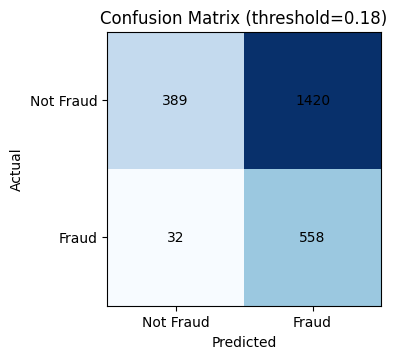

array([[ 389, 1420],
       [  32,  558]])

In [9]:
cm = confusion_matrix(y_test, pred_test)
fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(cm, cmap='Blues')
for (i, j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Not Fraud', 'Fraud'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Not Fraud', 'Fraud'])
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (threshold={THRESHOLD})')
plt.tight_layout(); plt.show()
cm

### 9. ROC-AUC

ROC-AUC: 0.6446


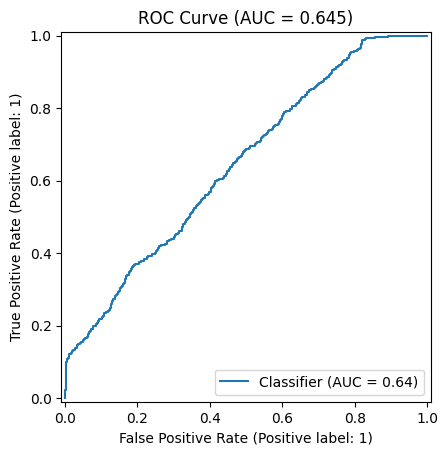

In [10]:
roc_auc = roc_auc_score(y_test, proba_test)
print('ROC-AUC:', round(roc_auc, 4))
RocCurveDisplay.from_predictions(y_test, proba_test)
plt.title(f'ROC Curve (AUC = {roc_auc:.3f})')
plt.show()

### 10. PR-AUC / Average Precision

PR-AUC (Average Precision): 0.4118


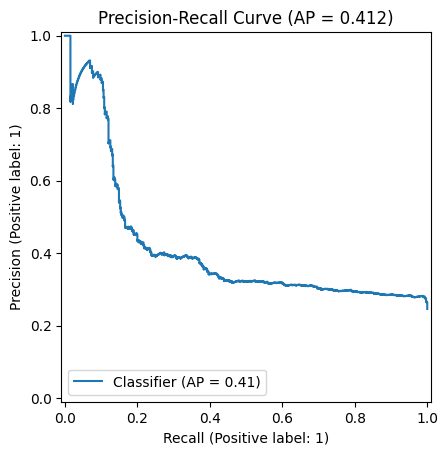

In [11]:
pr_auc = average_precision_score(y_test, proba_test)
print('PR-AUC (Average Precision):', round(pr_auc, 4))
PrecisionRecallDisplay.from_predictions(y_test, proba_test)
plt.title(f'Precision-Recall Curve (AP = {pr_auc:.3f})')
plt.show()

### 11. Selected threshold — summary of final metrics

In [12]:
precision, recall, f1, _ = precision_recall_fscore_support(y_test, pred_test, labels=[1], zero_division=0)
summary = {
    'Selected threshold': THRESHOLD,
    'Fraud Precision': round(float(precision[0]), 4),
    'Fraud Recall': round(float(recall[0]), 4),
    'Fraud F1': round(float(f1[0]), 4),
    'ROC-AUC': round(float(roc_auc), 4),
    'PR-AUC': round(float(pr_auc), 4),
}
summary

{'Selected threshold': 0.18,
 'Fraud Precision': 0.2821,
 'Fraud Recall': 0.9458,
 'Fraud F1': 0.4346,
 'ROC-AUC': 0.6446,
 'PR-AUC': 0.4118}

## 12. Save final model

Note: because `pipeline` includes a custom `FraudCleaner` /
`QuantileClipper` from `fraud_preprocessing.py`, that module must be
importable (i.e. on `sys.path` / next to the notebook) whenever this
`.pkl` file is loaded again.

In [13]:
joblib.dump(pipeline, '../model/vehicle_insurance_fraud_best_model.pkl')
print('Saved model to ../model/vehicle_insurance_fraud_best_model.pkl')

Saved model to ../model/vehicle_insurance_fraud_best_model.pkl
